This is a notebook to validate `cloelib` against `CosmoSIS` at the power spectra level. Since `CosmoSIS` has a different structure than `cloelib` (and`CCL`), it is computed outside from this notebook and here we just read and compare its output for simplicity.

 As a first test, we implement a simple configuration consisting of:
-  6 redshift bins 
-  Gaussian redshift distributions
-  Constant galaxy bias b=1 for all bins
-  No IA, no magnification

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
import os
import time

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
#from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el

import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)


## 1. Define Cosmology
- $\Lambda$-CDM
- No neutrinos
- Mead2020 halofit model for non-linear P(k)

In [2]:
cosmo_dict = {
    'H0': 67.7,
    'Omega_c': 0.25,
    'Omega_b': 0.05,
    'Omega_k':0,
    'omch2': 0.25*0.677**2,
    'ombh2': 0.05*0.677**2,
    'w0': -1,
    'wa':0,
    'ns':0.95,
    'As':2e-9,
    'mnu':0.0,
    'nnu':3.044,
    'Neff':3.044,
    'halofit_version':'mead2020'
}

# Redshift array to compute power spectra and define n(z)'s
zs = np.linspace(1e-4, 3., 256) 

## 2. Compute and compare power spectra
Here we give the cosmology dictionary as an input to `CAMB` and `cloelib` to compute linear and non-linear power spectra. `cloelib` and `CosmoSIS` call `CAMB` internally so we want to check same results are obtained.

### 2.1. `CAMB` 


In [3]:
import camb
from camb import model
print('Using CAMB %s'%(camb.__version__))

# Give cosmology dictionary to CAMB
pars = camb.set_params(H0=cosmo_dict['H0'], 
                       ombh2=cosmo_dict['ombh2'],
                       omch2=cosmo_dict['omch2'], 
                       mnu=cosmo_dict['mnu'],
                       nnu=cosmo_dict['nnu'],
                       standard_neutrino_neff=cosmo_dict['Neff'], 
                       omk=cosmo_dict['Omega_k'],  
                       As=cosmo_dict['As'],
                       ns=cosmo_dict['ns'], 
                       halofit_version=cosmo_dict['halofit_version']
                       )

pars.set_matter_power(redshifts=zs, kmax=300) 

# Compute linear P(k)
results = camb.get_results(pars)
ks = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False,)[0]
pk_lin_camb = results.get_matter_power_interpolator(nonlinear=False, hubble_units=False, k_hunit=False, extrap_kmax=300).P(0,ks)

# Compute non-linear P(k) with Mead2020 halofit version
pk_nonlin_camb = results.get_matter_power_interpolator(nonlinear=True, hubble_units=False, k_hunit=False).P(0,ks)

Using CAMB 1.5.9
Note: redshifts have been re-sorted (earliest first)


### 2.2 `cloelib` 

In [5]:
# CAMB is used here as the external code to compute background and perturbations
background = CAMBBackground(H0 = cosmo_dict['H0'], 
                            Omega_cdm0 = cosmo_dict['Omega_c'], 
                            Omega_b0 = cosmo_dict['Omega_b'], 
                            w0 = cosmo_dict['w0'], 
                            wa = cosmo_dict['wa'], 
                            Omega_k0 = cosmo_dict['Omega_k'], 
                            ns = cosmo_dict['ns'], 
                            As = cosmo_dict['As'],
                            mnu = cosmo_dict['mnu'],
                            gamma_MG=0
                            )

linear_perturbations = CAMBLinearPerturbations(background, zs)
pk_lin_cloe = linear_perturbations.matter_power_spectrum(0, ks) #(z, k)

nonlinear_perturbations = CAMBNonLinearPerturbations(background, zs, nonlinear_model = cosmo_dict['halofit_version']) 
pk_nonlin_cloe = nonlinear_perturbations.matter_power_spectrum(0, ks)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


### 2.3. `CosmoSIS`

Data can be downloaded from Zenodo: https://zenodo.org/records/15260145

In [7]:
# Local path to CosmoSIS output files
path_cosmosis = '/Users/your_local_path/cosmosis_data/'

k_lin_cosmosis = np.loadtxt(path_cosmosis + 'matter_power_lin/k_h.txt')*(cosmo_dict['H0']/100) #convert to [Mpc^-1] [Mpc^3] units
pk_lin_cosmosis = np.loadtxt(path_cosmosis + 'matter_power_lin/p_k.txt')/(cosmo_dict['H0']/100)**3

k_nonlin_cosmosis = np.loadtxt(path_cosmosis + 'matter_power_nl/k_h.txt')*(cosmo_dict['H0']/100)
pk_nonlin_cosmosis = np.loadtxt(path_cosmosis + 'matter_power_nl/p_k.txt')/(cosmo_dict['H0']/100)**3

pk_lin_cosmosis = np.interp(ks, k_lin_cosmosis, pk_lin_cosmosis[0])
pk_nonlin_cosmosis = np.interp(ks, k_nonlin_cosmosis, pk_nonlin_cosmosis[0])


### 2.4. Compare power spectra

$\% \: \rm{diff.} = \frac{P_A(k)-P_B(k)}{P_B(k)} \times 100$

#### 2.4.1. Linear P(k)

/Users/jcoloma/miniconda3/envs/envCLOE/lib/python3.10/site-packages/matplotlib/scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


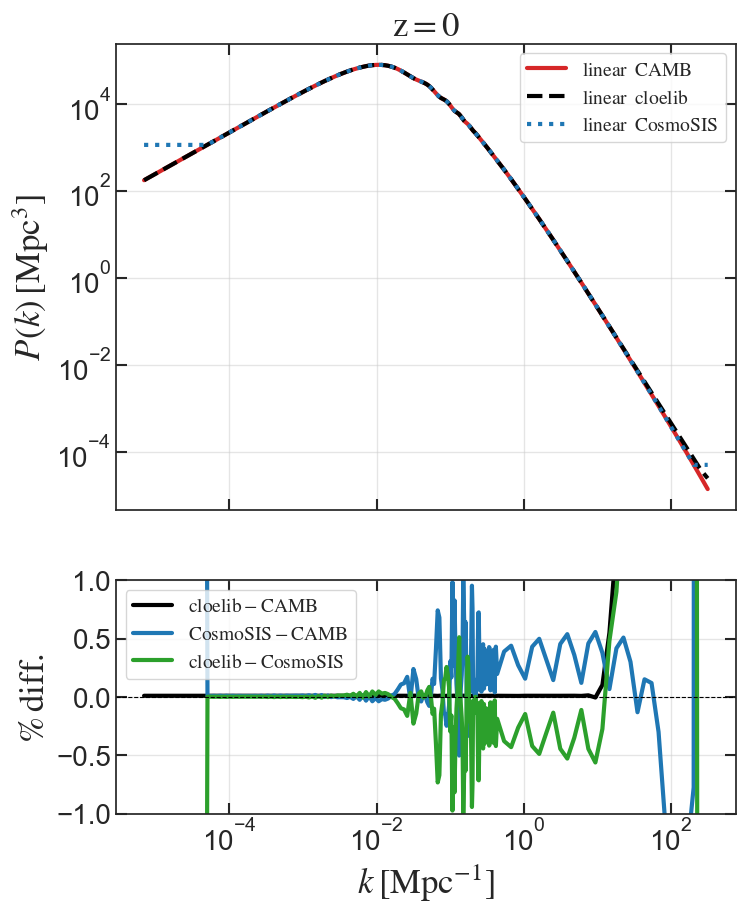

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'$\rm{z=0}$')
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$', fontsize=25)
axs[0].loglog(ks,  pk_lin_camb, color='tab:red',  label=r'$\rm{linear\;\;CAMB}$')
axs[0].loglog(ks,  pk_lin_cloe, color='black', ls='--', label=r'$\rm{linear\;\;cloelib}$')
axs[0].loglog(ks,  pk_lin_cosmosis, color='tab:blue', ls=':', label=r'$\rm{linear\;\;CosmoSIS}$')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\: [\rm{Mpc}^{-1}]$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(ks, (pk_lin_cloe - pk_lin_camb)/pk_lin_camb*100, color='black', ls='-', label=r'$\rm{cloelib-CAMB}$')
axs[1].plot(ks, (pk_lin_cosmosis - pk_lin_camb)/pk_lin_camb*100, color='tab:blue', ls='-', label=r'$\rm{CosmoSIS-CAMB}$')
axs[1].plot(ks, (pk_lin_cloe - pk_lin_cosmosis)/pk_lin_cloe*100, color='tab:green', ls='-', label=r'$\rm{cloelib-CosmoSIS}$')

axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-1, 1])
axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)



#### 2.4.2. Non linear P(k)

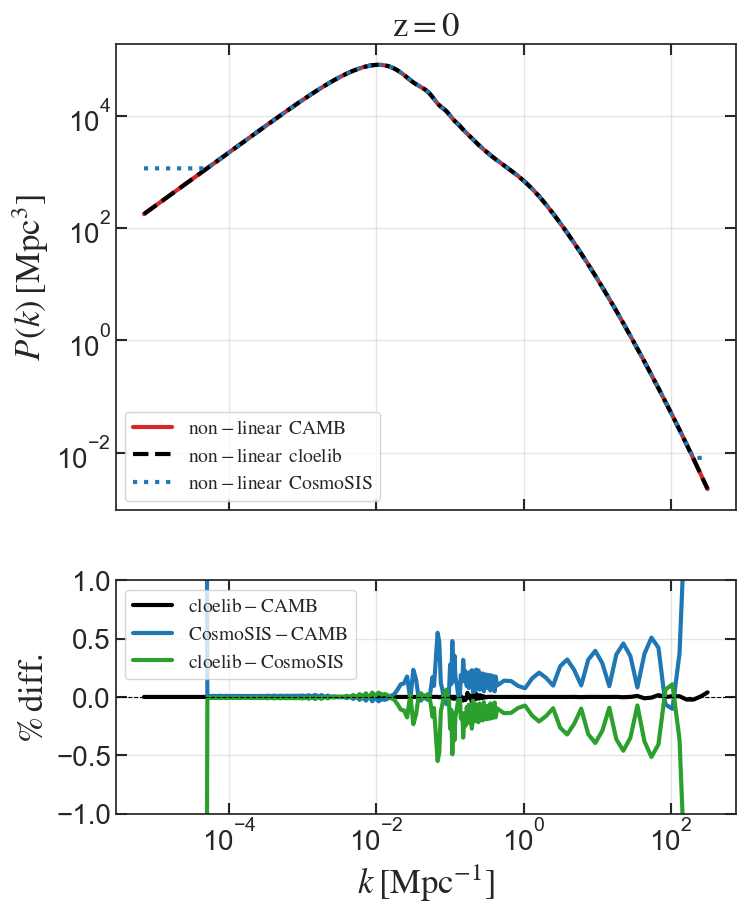

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)

axs[0].set_title(r'$\rm{z=0}$')
axs[0].set_ylabel(r'$P_{\rm}(k)\: [\rm{Mpc}^3]$', fontsize=25)
axs[0].loglog(ks,  pk_nonlin_camb, color='tab:red',  label=r'$\rm{non-linear\;\;CAMB}$')
axs[0].loglog(ks,  pk_nonlin_cloe, color='black', ls='--', label=r'$\rm{non-linear\;\;cloelib}$')
axs[0].loglog(ks,  pk_nonlin_cosmosis, color='tab:blue', ls=':', label=r'$\rm{non-linear\;\;CosmoSIS}$')

axs[0].legend()

## Ratios
axs[1].set_xlabel(r'$k\: [\rm{Mpc}^{-1}]$', fontsize=25)
axs[1].set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
axs[1].plot(ks, (pk_nonlin_cloe - pk_nonlin_camb)/pk_nonlin_camb*100, color='black', ls='-', label=r'$\rm{cloelib-CAMB}$')
axs[1].plot(ks, (pk_nonlin_cosmosis - pk_nonlin_camb)/pk_nonlin_camb*100, color='tab:blue', ls='-', label=r'$\rm{CosmoSIS-CAMB}$')
axs[1].plot(ks, (pk_nonlin_cloe - pk_nonlin_cosmosis)/pk_nonlin_cloe*100, color='tab:green', ls='-', label=r'$\rm{cloelib-CosmoSIS}$')

axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_ylim([-1, 1])
axs[1].axhline(0, 0, 300, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)

## 3. Redshift distributions

### 3.1. Read file from Zenodo
https://zenodo.org/records/15092862/files/nz_example.fits

In [11]:
local_path = '/Users/jcoloma/phd/ice/cloe-org/cloelib/notebooks/data/' # change with yours (!)
z, nz_heracles = el.photo.redshift_distributions(local_path + 'nz_example_heracles.fits')

# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)


# Resampling the normalized n(z) with len(zs)=256 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
dndz_pos = np.zeros([len(nz_heracles.keys()), len(zs)])
for i in range(6):
    dndz_pos[i,:] = np.interp(zs, z, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
dndz_she = np.zeros([len(nz_heracles.keys()), len(zs)])
for i in range(6):
    dndz_she[i,:] = np.interp(zs, z, my_dndz_she[i,:])

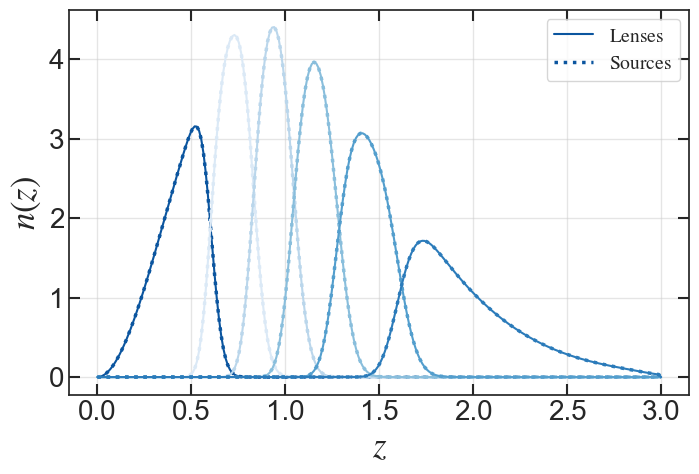

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(8,5))

axs.set_ylabel(r'$n(z)$', fontsize=25)
axs.set_xlabel(r'$z$', fontsize=25)

for i in range(6):
    if i==0:
        axs.plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1], label = r'$\rm{Lenses}$')
        axs.plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1], label = r'$\rm{Sources}$')

    else:
        axs.plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1])
        axs.plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1])


axs.tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
axs.tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
axs.grid(alpha=0.5)

axs.legend()

## 4. Tracers
Tracers define the kernels for the different probes. We use:
-  Constant bias = 1 for all bins
- No IA, no magnification

### 4.1. `cloelib`

In [13]:
tracer_pos_cloe = PositionsTracer(perturbations=nonlinear_perturbations, 
                            dndz=dndz_pos,
                            z=zs,
                            galaxy_bias_model='per_bin',
                            nuisance_params={'b1_photo_bin1': 1.0, 'b1_photo_bin2': 1.0, 'b1_photo_bin3': 1.0, 'b1_photo_bin4': 1.0,
                                             'b1_photo_bin5': 1.0, 'b1_photo_bin6': 1.0}

                            )

tracer_she_cloe = ShearTracer(perturbations=nonlinear_perturbations, 
                            dndz=dndz_she,
                            z=zs,
                            nuisance_params={'AIA': 0.0, 'CIA': 0.0, 'EtaIA':0.0})  

In [14]:
nl = 100
ells = np.logspace(1., np.log10(3000.), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
twopoint_shepos = AngularTwoPoint(tracer_she_cloe, tracer_pos_cloe)
twopoint_sheshe = AngularTwoPoint(tracer_she_cloe, tracer_she_cloe)

cells_gg_cloe = twopoint_pospos.get_Cl(ells, nl, ks)
cells_gE_cloe = twopoint_shepos.get_Cl(ells, nl, ks)
cells_EE_cloe = twopoint_sheshe.get_Cl(ells, nl, ks)

### 4.2. `CosmoSIS`

In [15]:
# Load C'ells files from local path

# Limber prefactor missing in CosmoSIS
lf_dl=(ells+0.5)**2/np.sqrt((ells+2.)*(ells+1.)*ells*(ells-1.))

ells_cosmosis = np.loadtxt(path_cosmosis + 'shear_cl/ell.txt')
cells_EE_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
cells_gg_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
cells_gE_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
for i in range(6):
    cells_EE_cosmosis[:,i,i] = np.loadtxt(path_cosmosis + 'shear_cl/bin_%s_%s.txt'%(str(i+1), str(i+1)))*(lf_dl**-2)
    cells_gg_cosmosis[:,i,i] = np.loadtxt(path_cosmosis + 'galaxy_cl/bin_%s_%s.txt'%(str(i+1), str(i+1)))
    cells_gE_cosmosis[:,i,i] = np.loadtxt(path_cosmosis + 'galaxy_shear_cl/bin_%s_%s.txt'%(str(i+1), str(i+1)))*(lf_dl**-1)

### 5.3. Compare angular power spectra
$\% \:\rm{diff.} = \frac{C_{\rm CCL}(\ell) - C_{\rm cloelib}(\ell)}{C_{\rm CCL}(\ell)} \times 100$

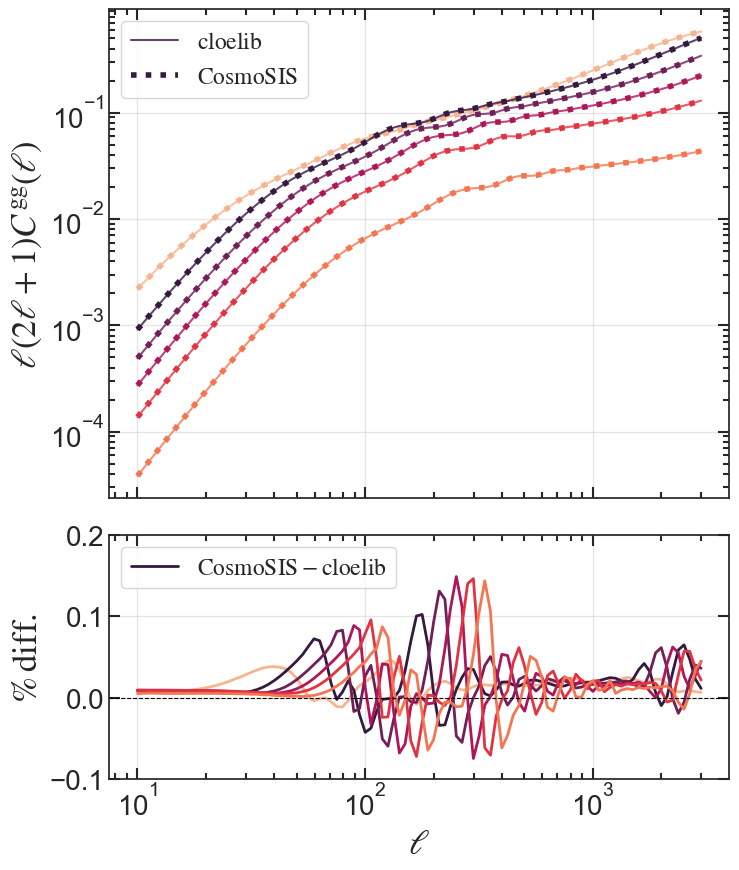

In [18]:
probe = 'gg' # Galaxy clustering
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_cosmosis = globals()[f'cells_{probe}_cosmosis']

fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=sns.color_palette("rocket", 6)[i-1], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cosmosis[:, i, i], color=sns.color_palette("rocket", 6)[i-1], ls=':', linewidth=4, label = r'$\rm{CosmoSIS}$')
    
        axs[1].plot(ells, (cells_cosmosis[:, i, i] - cells_cloe[:, i, i])/cells_cosmosis[:, i, i]*100, linewidth=2, alpha=1, color=sns.color_palette("rocket", 6)[i-1], label = r'$\rm{CosmoSIS-cloelib}$')

    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], linewidth=1.5, alpha=0.8, color=sns.color_palette("rocket", 6)[i-1])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cosmosis[:, i, i], ls=':', linewidth=4, color=sns.color_palette("rocket", 6)[i-1])

        axs[1].plot(ells, (cells_cosmosis[:, i, i] - cells_cloe[:, i, i])/cells_cosmosis[:, i, i]*100, linewidth=2, alpha=1, color=sns.color_palette("rocket", 6)[i-1])

axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


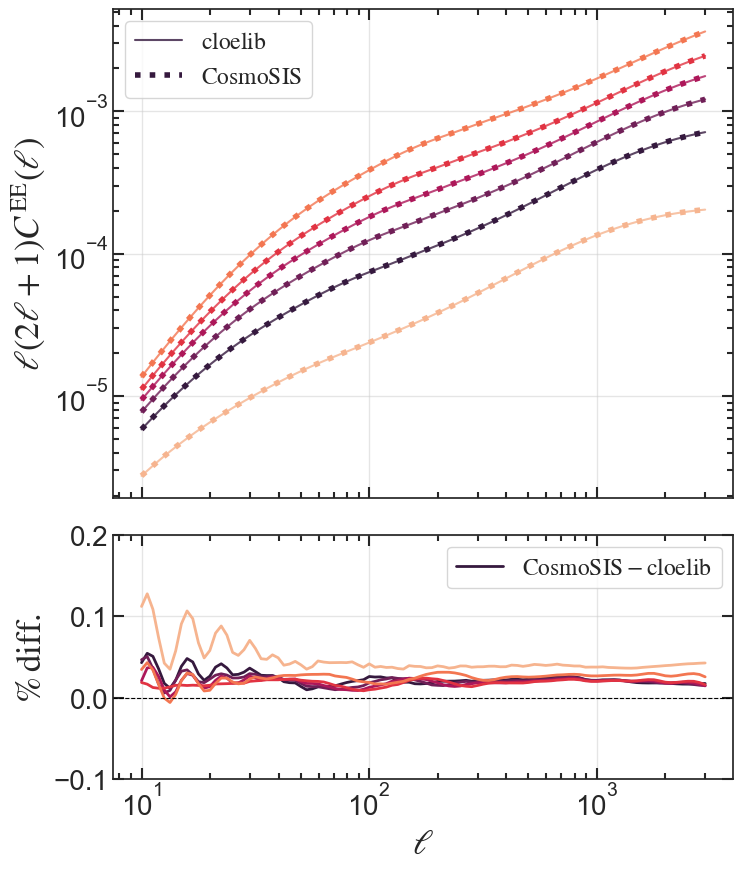

In [19]:
probe = 'EE' # Weak Lensing
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_cosmosis = globals()[f'cells_{probe}_cosmosis']

fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=sns.color_palette("rocket", 6)[i-1], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cosmosis[:, i, i], color=sns.color_palette("rocket", 6)[i-1], ls=':', linewidth=4, label = r'$\rm{CosmoSIS}$')
    
        axs[1].plot(ells, (cells_cosmosis[:, i, i] - cells_cloe[:, i, i])/cells_cosmosis[:, i, i]*100, linewidth=2, alpha=1, color=sns.color_palette("rocket", 6)[i-1], label = r'$\rm{CosmoSIS-cloelib}$')

    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], linewidth=1.5, alpha=0.8, color=sns.color_palette("rocket", 6)[i-1])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cosmosis[:, i, i], ls=':', linewidth=4, color=sns.color_palette("rocket", 6)[i-1])

        axs[1].plot(ells, (cells_cosmosis[:, i, i] - cells_cloe[:, i, i])/cells_cosmosis[:, i, i]*100, linewidth=2, alpha=1, color=sns.color_palette("rocket", 6)[i-1])

axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)


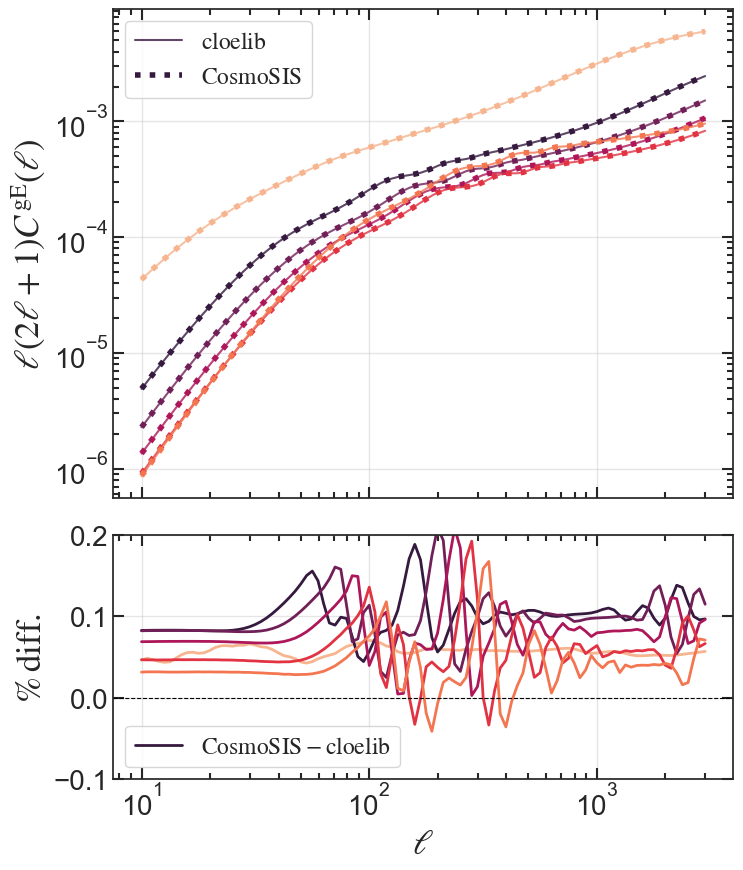

In [20]:
probe = 'gE' # Galaxy Galaxy Lensing
cells_cloe = globals()[f'cells_{probe}_cloe']
cells_cosmosis = globals()[f'cells_{probe}_cosmosis']

fig, axs = plt.subplots(2, 1, figsize=(8,10),  gridspec_kw={'height_ratios':[2,1] }, sharex=True)
fig.subplots_adjust(hspace=0.1)

axs[0].set_ylabel(r'$\ell (2\ell +1)C^{\rm ' + probe + '}(\ell)$', fontsize=25)
axs[1].set_xlabel(r'$\ell$', fontsize=25)
axs[1].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=25)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

for i in range(6):
    if i==1:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], color=sns.color_palette("rocket", 6)[i-1], linewidth=1.5, alpha=0.8, label = r'$\rm{cloelib}$')
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cosmosis[:, i, i], color=sns.color_palette("rocket", 6)[i-1], ls=':', linewidth=4, label = r'$\rm{CosmoSIS}$')
    
        axs[1].plot(ells, (cells_cosmosis[:, i, i] - cells_cloe[:, i, i])/cells_cosmosis[:, i, i]*100, linewidth=2, alpha=1, color=sns.color_palette("rocket", 6)[i-1], label = r'$\rm{CosmoSIS-cloelib}$')

    else:
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cloe[:, i, i], linewidth=1.5, alpha=0.8, color=sns.color_palette("rocket", 6)[i-1])
        axs[0].loglog(ells, ells*(2*ells+1)*cells_cosmosis[:, i, i], ls=':', linewidth=4, color=sns.color_palette("rocket", 6)[i-1])

        axs[1].plot(ells, (cells_cosmosis[:, i, i] - cells_cloe[:, i, i])/cells_cosmosis[:, i, i]*100, linewidth=2, alpha=1, color=sns.color_palette("rocket", 6)[i-1])

axs[1].set_ylim([-0.1, 0.2])
axs[0].legend(fontsize=17)
axs[1].legend(fontsize=17)
axs[1].axhline(0, 0, 3e3, lw=.8, ls='--', color='black')

for i in range(2):
    axs[i].tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
    axs[i].tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
    axs[i].grid(alpha=0.5)
